Python: 3.14.5 (tags/v3.14.5:5607950, May 10 2026, 10:43:50) [MSC v.1944 64 bit (AMD64)]
Environment: c:\Users\user\Desktop\Intro to AI Labs\ai_env\Scripts\python.exe
NumPy: 2.4.6
Pandas: 3.0.3
Border Matrix:
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
Means after normalization: [-2.60902411e-17  1.55431223e-17 -8.88178420e-18]
Stds after normalization: [1. 1. 1.]
True theta: [ 2.5 -1.2  3.7]
Estimated theta: [ 2.51723721 -1.19783796  3.72399266]
major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64

Best Major:
major
CS         76.425184
Biology    75.503150
Physics    75.406509
Math       74.683689
Name: exam_score, dtype: float64

Correlation:
               hours_studied  exam_score
hours_studied       1.000000   -0.055981
exam_score         -0.055981    1.000000


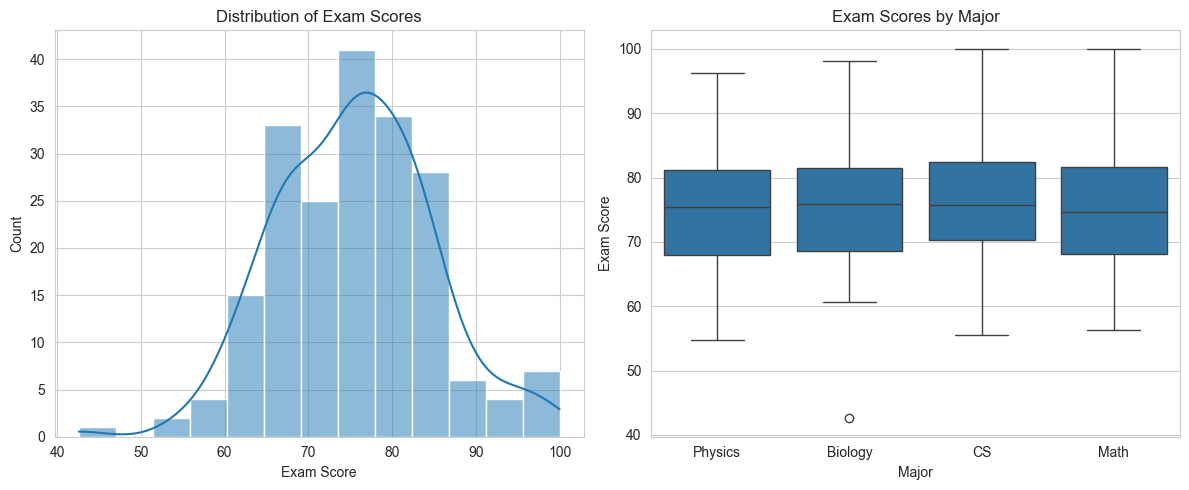

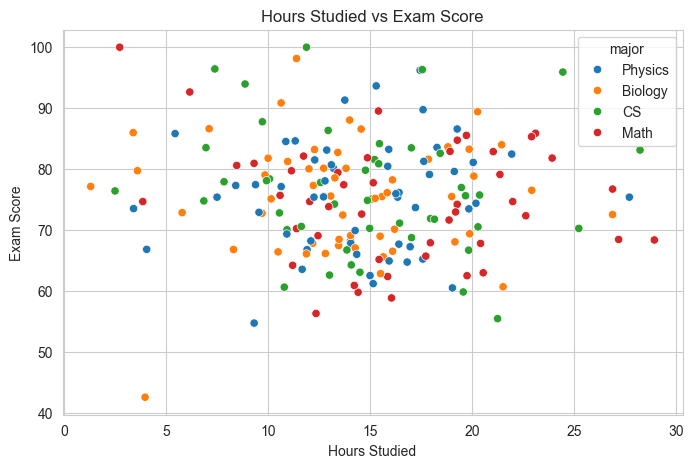

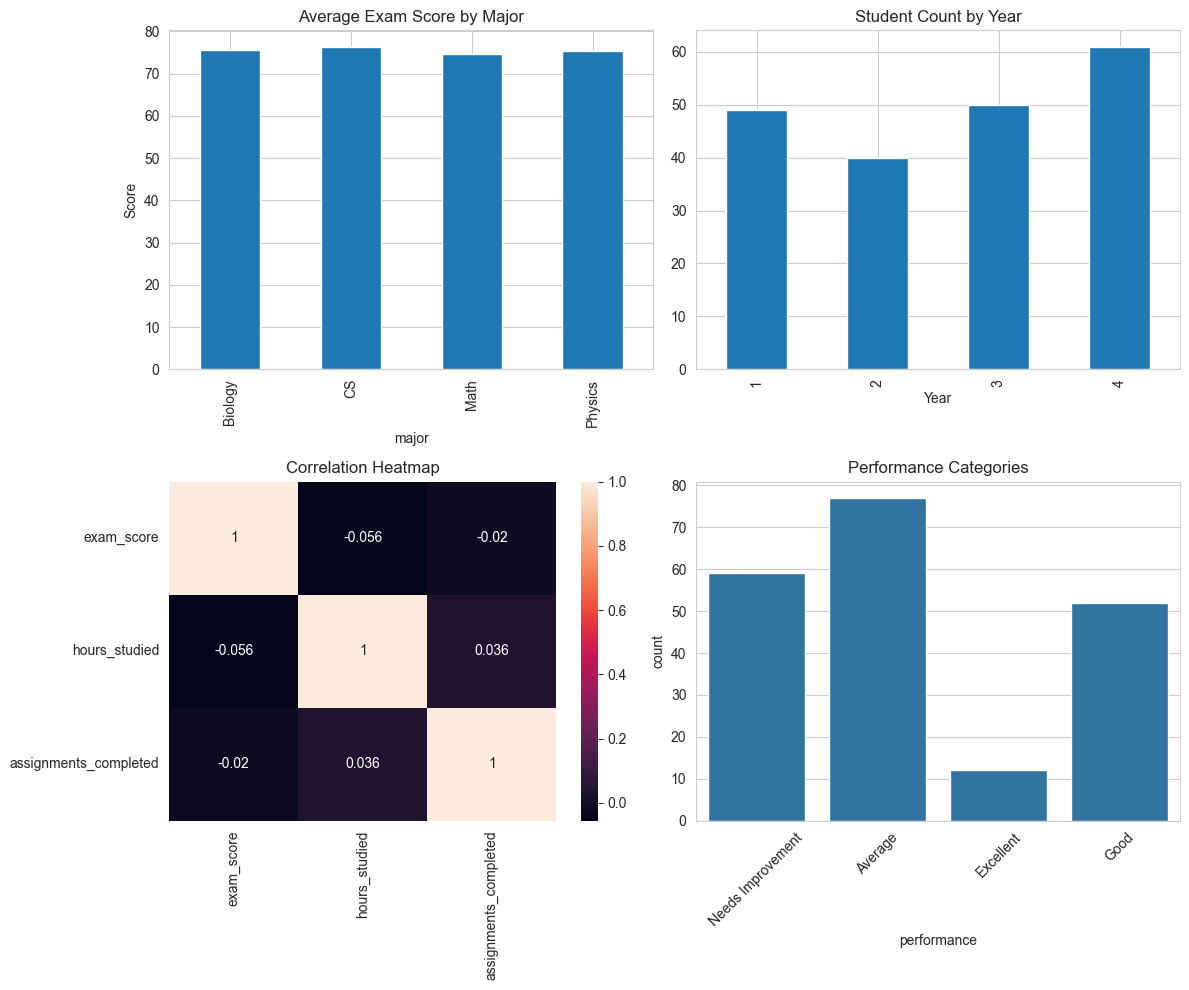

KeyError: 'age_group'

In [ ]:
import sys
import numpy as np
import pandas as pd

print("Python:", sys.version)
print("Environment:", sys.executable)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

# Task 1

import numpy as np

matrix = np.ones((5, 5))
matrix[1:4, 1:4] = 0

print("Border Matrix:")
print(matrix)


# Task 2
np.random.seed(42)
random_data = np.random.randn(100, 3)

mean = random_data.mean(axis=0)
std = random_data.std(axis=0)

normalized = (random_data - mean) / std

print("Means after normalization:", normalized.mean(axis=0))
print("Stds after normalization:", normalized.std(axis=0))


# Task 3
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])

y = X @ true_theta + np.random.randn(50) * 0.1

theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("True theta:", true_theta)
print("Estimated theta:", theta_hat)

import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)
df.head()

df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

df.isnull().sum()


df['exam_score'] = df['exam_score'].fillna(
    df.groupby('major')['exam_score'].transform('mean')
)

df['hours_studied'] = df['hours_studied'].fillna(
    df.groupby('year')['hours_studied'].transform('median')
)

df.isnull().sum()

# Average exam 
print(df.groupby('major')['exam_score'].mean())

# Best performing major
print("\nBest Major:")
print(df.groupby('major')['exam_score'].mean().sort_values(ascending=False))

# Correlation
print("\nCorrelation:")
print(df[['hours_studied', 'exam_score']].corr())

def categorize(score):
    if score > 90:
        return 'Excellent'
    elif score >= 80:
        return 'Good'
    elif score >= 70:
        return 'Average'
    else:
        return 'Needs Improvement'

df['performance'] = df['exam_score'].apply(categorize)

df['performance'].value_counts()


summary = df.groupby(['major', 'year']).agg(
    student_count=('student_id', 'count'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours=('hours_studied', 'mean')
)

summary


df.nlargest(5, 'exam_score')
df.pivot_table(
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
)





# Exercise 6

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


# Task 1

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram 
sns.histplot(df['exam_score'], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Exam Scores")
axes[0].set_xlabel("Exam Score")

# Boxplot by major
sns.boxplot(data=df, x='major', y='exam_score', ax=axes[1])
axes[1].set_title("Exam Scores by Major")
axes[1].set_xlabel("Major")
axes[1].set_ylabel("Exam Score")

plt.tight_layout()
plt.show()



# Task 2: Relationship (Hours Studied vs Score)

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    hue='major'
)

plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.show()



# Task 3
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Average exam score by major
df.groupby('major')['exam_score'].mean().plot(kind='bar', ax=axes[0, 0])
axes[0, 0].set_title("Average Exam Score by Major")
axes[0, 0].set_ylabel("Score")

# 2. Student count by year
df['year'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title("Student Count by Year")
axes[0, 1].set_xlabel("Year")

# 3. Correlation heatmap
sns.heatmap(
    df[['exam_score', 'hours_studied', 'assignments_completed']].corr(),
    annot=True,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Correlation Heatmap")

# 4. Performance distribution
sns.countplot(data=df, x='performance', ax=axes[1, 1])
axes[1, 1].set_title("Performance Categories")
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

n_customers = 500

ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_frequency = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_frequency,
    'avg_purchase_value': avg_purchase_value
})

customers.head()



max_freq = customers['purchase_frequency'].max()

customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_freq)

customers['CLV'] = (
    customers['purchase_frequency']
    * customers['avg_purchase_value']
    * (1 + customers['churn_risk'])
)

customers.head()

summary = customers.groupby('age_group').agg(
    customer_count=('age', 'count'),
    avg_income=('income', 'mean'),
    avg_clv=('CLV', 'mean'),
    total_clv=('CLV', 'sum')
)

summary


top_10_percent = customers.nlargest(int(0.1 * len(customers)), 'CLV')

top_10_percent.head()

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=customers,
    x='income',
    y='CLV',
    hue='age_group'
)

plt.title("Income vs Customer Lifetime Value")
plt.show()

customers.groupby('age_group')['CLV'].mean().plot(kind='bar')

plt.title("Average CLV by Age Group")
plt.ylabel("CLV")
plt.show()

plt.figure(figsize=(6, 4))

sns.heatmap(
    customers[['age', 'income', 'purchase_frequency', 'avg_purchase_value', 'CLV']].corr(),
    annot=True
)

plt.title("Feature Correlation Heatmap")
plt.show()